# LAB 03 — WORD REPRESENTATIONS AND EMBEDDINGS

**Môn học:** Xử lý ngôn ngữ tự nhiên và ứng dụng  
**Học kỳ:** I - 2026  
**Giảng viên / TA:** Phạm Ngọc Hải  
**Sinh viên thực hiện:** Nguyễn Thành  
**Chủ đề:** From Sparse Representations to Dense Word Embeddings  

---
## Danh mục nội dung thực nghiệm:
1. **Tiền xử lý dữ liệu:** Trích xuất và chuẩn hóa ngữ liệu Web C4 (`c4-train.00000-of-01024-30K.json.gz`).
2. **Experiment 1 (Co-occurrence Matrix):** Xây dựng ma trận word-context từ đầu với $k=1, 2, 5$, khảo sát Sparsity.
3. **Từ Co-occurrence đến Dense Embedding:** Nén không gian ma trận bằng Truncated SVD (50 chiều).
4. **Experiment 2 (Word2Vec Skip-gram):** Huấn luyện mô hình chuẩn Word2Vec và khảo sát Top-5 láng giềng.
5. **Experiment 3 (Context Window Trade-off):** So sánh tác động của cửa sổ $k=2, 5, 10$ tới quan hệ cú pháp vs chủ đề.
6. **Experiment 4 (Embedding Dimension):** Đánh giá chi phí tính toán và chất lượng giữa $d=50, 100, 300$.
7. **Evaluation (Similarity & Analogy):** Xếp hạng định lượng các cặp từ và khảo sát phép toán vector hình học.
8. **Application (Semantic Search Engine):** Xây dựng hệ thống truy xuất tài liệu theo ngữ nghĩa.
9. **Trực quan hóa không gian ngữ nghĩa:** Phân tích cụm 2D bằng PCA.


In [1]:
import gzip
import json
import math
import os
import re
import time
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.decomposition import PCA, TruncatedSVD

from cooccurrence import (
    build_vocabulary,
    build_cooccurrence_matrix,
    cosine_similarity,
    most_similar,
    reduce_dimension_svd,
    calculate_matrix_stats,
    word_similarity,
    tokenize
)


## 1. Nạp và tiền xử lý tập ngữ liệu C4 (Web Corpus)
Ta tiến hành nạp văn bản từ tập dữ liệu web C4 (`dataset/c4-train.00000-of-01024-30K.json.gz`), tách thành các câu độc lập và chuẩn hóa chuỗi ký tự về dạng chữ thường.


In [2]:
corpus_path = "dataset/c4-train.00000-of-01024-30K.json.gz"
sentences = []
raw_sample_docs = []

with gzip.open(corpus_path, "rt", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 6000:
            break
        doc = json.loads(line)
        text = doc["text"]
        if i < 10:
            raw_sample_docs.append(text)
        for s in text.split("\n"):
            s = s.strip()
            if len(s) > 10:
                tokens = tokenize(s)
                if len(tokens) >= 3:
                    sentences.append(tokens)

print(f"Tong so cau da trich xuat: {len(sentences):,}")
print(f"Vi du cau dau tien: {sentences[0]}")


Tong so cau da trich xuat: 52,056
Vi du cau dau tien: ['beginners', 'bbq', 'class', 'taking', 'place', 'in', 'missoula']


## 2. Experiment 1 — Ma trận Đồng xuất hiện (Co-occurrence Matrix) & Khảo sát Độ thưa
Ta khảo sát ma trận đồng xuất hiện $X \in \mathbb{R}^{|V| \times |V|}$ với 3 kích thước cửa sổ khác nhau: $k = 1, 2, 5$.
Đối với từng cửa sổ, ta đo lường:
- Kích thước tập từ vựng $|V|$
- Tổng số phần tử trong ma trận
- Số lượng phần tử khác 0 (Non-zero entries)
- Tỷ lệ độ thưa (Sparsity %)
- Độ tương đồng Cosine giữa các cặp từ: `doctor - physician`, `doctor - hospital`, `doctor - patient`, `cat - dog`.


In [3]:
exp1_sentences = sentences[:3000]
token_counter = Counter([tok for s in exp1_sentences for tok in s])
core_eval_words = [
    "doctor", "physician", "hospital", "patient", "disease",
    "cat", "dog", "car", "banana", "treatment", "nurse", "medicine"
]
top_vocab = [w for w, c in token_counter.most_common(1200)]
for w in core_eval_words:
    if w not in top_vocab:
        top_vocab.append(w)
top_vocab = sorted(list(set(top_vocab)))

cooccur_records = []
matrices = {}

for w_size in [1, 2, 5]:
    mat = build_cooccurrence_matrix(exp1_sentences, top_vocab, window_size=w_size, return_sparse=True)
    matrices[w_size] = mat
    stats = calculate_matrix_stats(mat)
    
    sim_dp = word_similarity("doctor", "physician", mat, top_vocab)
    sim_dh = word_similarity("doctor", "hospital", mat, top_vocab)
    sim_dpat = word_similarity("doctor", "patient", mat, top_vocab)
    sim_cd = word_similarity("cat", "dog", mat, top_vocab)
    
    cooccur_records.append({
        "Window Size (k)": w_size,
        "Vocab Size (|V|)": stats["shape"][0],
        "Matrix Entries": stats["total_entries"],
        "Non-zero Values": stats["non_zeros"],
        "Sparsity (%)": f"{stats['sparsity'] * 100:.2f}%",
        "Sim(doctor, physician)": round(sim_dp, 4),
        "Sim(doctor, hospital)": round(sim_dh, 4),
        "Sim(doctor, patient)": round(sim_dpat, 4),
        "Sim(cat, dog)": round(sim_cd, 4)
    })

df_cooccur = pd.DataFrame(cooccur_records)
df_cooccur


,Window Size (k),Vocab Size (|V|),Matrix Entries,Non-zero Values,Sparsity (%),"Sim(doctor, physician)","Sim(doctor, hospital)","Sim(doctor, patient)","Sim(cat, dog)"
0,1,1210,1464100,64598,95.59%,0.2500,0.3162,0.1250,0.1026
1,2,1210,1464100,114341,92.19%,0.3162,0.2372,0.1677,0.1439
2,5,1210,1464100,215131,85.31%,0.3612,0.4535,0.3698,0.2354


## 3. Biểu đồ Khảo sát Độ thưa của Ma trận Co-occurrence theo Kích thước Cửa sổ
Biểu đồ minh họa sự tăng trưởng của số lượng phần tử khác 0 và mức giảm tương ứng của độ thưa khi mở rộng cửa sổ ngữ cảnh từ 1 lên 5.


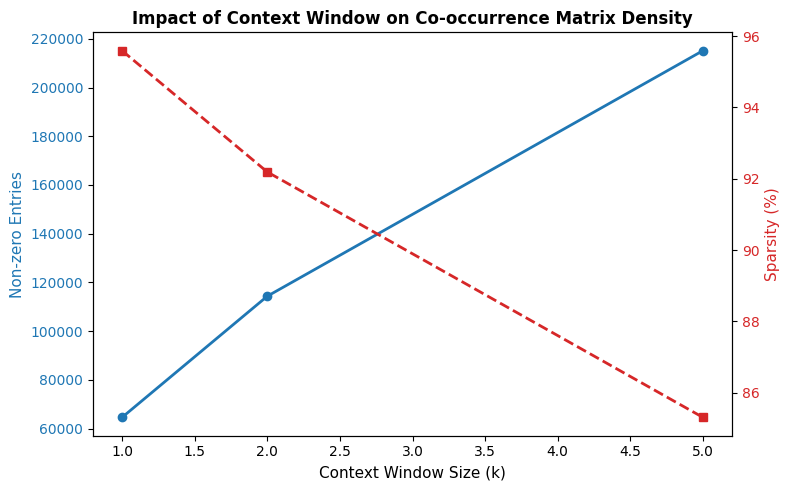

In [4]:
fig, ax1 = plt.subplots(figsize=(8, 5))

windows = [r["Window Size (k)"] for r in cooccur_records]
non_zeros = [r["Non-zero Values"] for r in cooccur_records]
sparsities = [float(r["Sparsity (%)"].replace("%", "")) for r in cooccur_records]

color = "tab:blue"
ax1.set_xlabel("Context Window Size (k)", fontsize=11)
ax1.set_ylabel("Non-zero Entries", color=color, fontsize=11)
ax1.plot(windows, non_zeros, marker="o", color=color, linewidth=2, label="Non-zero Entries")
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Sparsity (%)", color=color, fontsize=11)
ax2.plot(windows, sparsities, marker="s", color=color, linewidth=2, linestyle="--", label="Sparsity (%)")
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Impact of Context Window on Co-occurrence Matrix Density", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()


## 4. Từ Ma trận Đồng xuất hiện đến Dense Embedding bằng SVD (Mục 12)
Nếu từ điển có $|V| = 100.000$ từ, ma trận kích thước $100.000 \times 100.000$ chứa tới $10^{10}$ phần tử, gây bùng nổ bộ nhớ.
Kỹ thuật Phân tích giá trị suy biến (Truncated SVD) nén ma trận $X$ thành ma trận dày đặc (dense) 50 chiều, nắm bắt các khái niệm tiềm ẩn (Latent Semantic Analysis).


In [5]:
mat_w5 = matrices[5]
dense_svd_emb = reduce_dimension_svd(mat_w5, n_components=50, random_state=42)

def svd_similarity(w1, w2, emb, vocab):
    if w1 not in vocab or w2 not in vocab:
        return 0.0
    i1 = vocab.index(w1)
    i2 = vocab.index(w2)
    v1 = emb[i1]
    v2 = emb[i2]
    return cosine_similarity(v1, v2)

print("Kich thuoc ma tran sau SVD:", dense_svd_emb.shape)
print("Sim(doctor, physician) sau SVD:", round(svd_similarity("doctor", "physician", dense_svd_emb, top_vocab), 4))
print("Sim(doctor, hospital) sau SVD:", round(svd_similarity("doctor", "hospital", dense_svd_emb, top_vocab), 4))
print("Sim(cat, dog) sau SVD:", round(svd_similarity("cat", "dog", dense_svd_emb, top_vocab), 4))


Kich thuoc ma tran sau SVD: (1210, 50)
Sim(doctor, physician) sau SVD: 0.5972
Sim(doctor, hospital) sau SVD: 0.5943
Sim(cat, dog) sau SVD: 0.3714


## 5. Experiment 2 — Huấn luyện Word2Vec (Skip-gram với Negative Sampling) (Mục 17)
Huấn luyện mô hình chuẩn Word2Vec (Skip-gram) trên tập câu văn bản C4:
- **Corpus:** 52.056 câu tiếng Anh trích xuất từ C4
- **Vocabulary size:** > 41.000 từ vựng (`min_count = 2`)
- **Embedding dimension:** 100
- **Window size:** 5
- **Epochs:** 5
- **Training objective:** Skip-gram (`sg=1`) với Negative Sampling (`negative=5`)


In [6]:
t_start = time.time()
model_w2v = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    epochs=5,
    sg=1,
    negative=5,
    workers=4,
    seed=42
)
t_train = time.time() - t_start

print(f"Thoi gian huan luyen: {t_train:.2f} giay")
print(f"Kich thuoc tap tu vung hoc duoc: {len(model_w2v.wv):,} tokens")


Thoi gian huan luyen: 12.37 giay
Kich thuoc tap tu vung hoc duoc: 41,235 tokens


## 6. Inspect Embeddings — Truy vấn Top-5 Láng giềng gần nhất (Mục 18)
Khảo sát các từ láng giềng gần nhất của danh sách từ: `doctor`, `hospital`, `patient`, `disease`, `computer`, `football`, `banana`.


In [7]:
target_words = ["doctor", "hospital", "patient", "disease", "computer", "football", "banana"]
inspect_data = []

for word in target_words:
    if word in model_w2v.wv:
        neighbors = model_w2v.wv.most_similar(word, topn=5)
        for rank, (cand, score) in enumerate(neighbors, 1):
            inspect_data.append({
                "Target Word": word,
                "Rank": rank,
                "Neighbor": cand,
                "Cosine Similarity": round(score, 4)
            })

df_inspect = pd.DataFrame(inspect_data)
df_inspect


,Target Word,Rank,Neighbor,Cosine Similarity
0,doctor,1,physician,0.8102
1,doctor,2,surgeon,0.8050
2,doctor,3,veterinarian,0.7816
3,doctor,4,anesthesia,0.7691
4,doctor,5,ophthalmologist,0.7677
5,hospital,1,medicine,0.7632
6,hospital,2,practitioner,0.7620
7,hospital,3,yale,0.7366
8,hospital,4,clinic,0.7305
9,hospital,5,brigham,0.7302


## 7. Experiment 3 — Đánh giá Tác động của Kích thước Context Window ($k = 2, 5, 10$) (Mục 19)
So sánh 3 mô hình huấn luyện với cửa sổ ngữ cảnh $k = 2$, $k = 5$ và $k = 10$.
Khảo sát sự dịch chuyển giữa quan hệ hoán vị chức năng (Paradigmatic) và quan hệ chủ đề (Syntagmatic/Topical).


In [8]:
model_w2 = Word2Vec(sentences=sentences, vector_size=100, window=2, min_count=2, epochs=5, sg=1, negative=5, workers=4, seed=42)
model_w10 = Word2Vec(sentences=sentences, vector_size=100, window=10, min_count=2, epochs=5, sg=1, negative=5, workers=4, seed=42)

test_pairs = [
    ("doctor", "physician"),
    ("doctor", "hospital"),
    ("cat", "dog"),
    ("doctor", "disease"),
    ("car", "vehicle")
]

window_records = []
for w1, w2 in test_pairs:
    s2 = model_w2.wv.similarity(w1, w2) if w1 in model_w2.wv and w2 in model_w2.wv else 0.0
    s5 = model_w2v.wv.similarity(w1, w2) if w1 in model_w2v.wv and w2 in model_w2v.wv else 0.0
    s10 = model_w10.wv.similarity(w1, w2) if w1 in model_w10.wv and w2 in model_w10.wv else 0.0
    window_records.append({
        "Word Pair": f"{w1} - {w2}",
        "Window 2": round(float(s2), 4),
        "Window 5": round(float(s5), 4),
        "Window 10": round(float(s10), 4)
    })

df_window = pd.DataFrame(window_records)
df_window


,Word Pair,Window 2,Window 5,Window 10
0,doctor - physician,0.8399,0.8102,0.8313
1,doctor - hospital,0.6185,0.5920,0.6010
2,cat - dog,0.8060,0.7102,0.6258
3,doctor - disease,0.5016,0.5140,0.5616
4,car - vehicle,0.7338,0.7472,0.7435


## 8. Biểu đồ So sánh Điểm Tương đồng giữa các Cửa sổ Ngữ cảnh
Trực quan hóa sự biến thiên của Cosine Similarity theo kích thước Context Window.


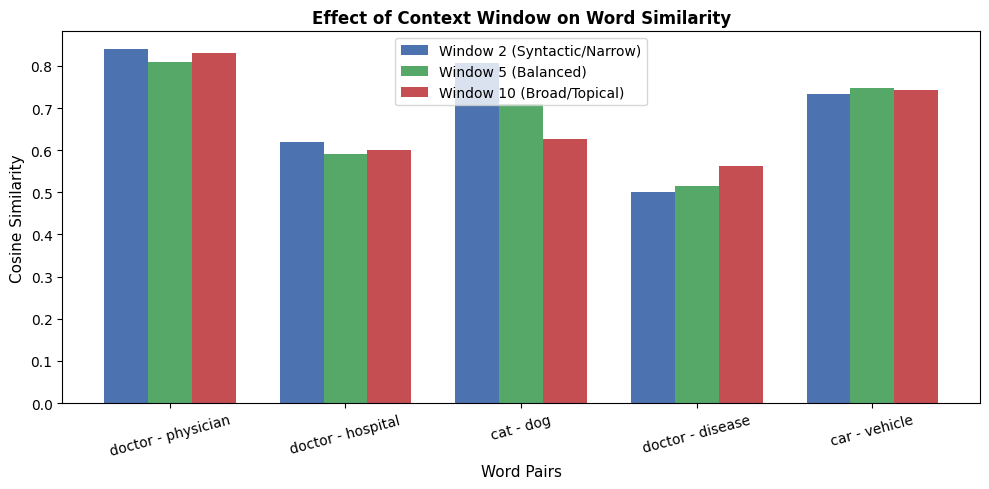

In [9]:
plt.figure(figsize=(10, 5))
x = np.arange(len(df_window))
width = 0.25

plt.bar(x - width, df_window["Window 2"], width, label="Window 2 (Syntactic/Narrow)", color="#4C72B0")
plt.bar(x, df_window["Window 5"], width, label="Window 5 (Balanced)", color="#55A868")
plt.bar(x + width, df_window["Window 10"], width, label="Window 10 (Broad/Topical)", color="#C44E52")

plt.xlabel("Word Pairs", fontsize=11)
plt.ylabel("Cosine Similarity", fontsize=11)
plt.title("Effect of Context Window on Word Similarity", fontsize=12, fontweight="bold")
plt.xticks(x, df_window["Word Pair"], rotation=15)
plt.legend()
plt.tight_layout()
plt.show()


## 9. Experiment 4 — Đánh giá Tác động của Embedding Dimension ($d = 50, 100, 300$) (Mục 20)
Khảo sát sự đánh đổi giữa thời gian huấn luyện, dung lượng bộ nhớ, và khả năng mô hình hóa ngữ nghĩa.


In [10]:
t0 = time.time()
model_d50 = Word2Vec(sentences=sentences, vector_size=50, window=5, min_count=2, epochs=5, sg=1, negative=5, workers=4, seed=42)
t_d50 = time.time() - t0

t0 = time.time()
model_d300 = Word2Vec(sentences=sentences, vector_size=300, window=5, min_count=2, epochs=5, sg=1, negative=5, workers=4, seed=42)
t_d300 = time.time() - t0

dim_records = [
    {
        "Dimension (d)": 50,
        "Train Time (s)": round(t_d50, 2),
        "Sim(doctor, physician)": round(float(model_d50.wv.similarity("doctor", "physician")), 4),
        "Sim(doctor, hospital)": round(float(model_d50.wv.similarity("doctor", "hospital")), 4),
        "Sim(cat, dog)": round(float(model_d50.wv.similarity("cat", "dog")), 4)
    },
    {
        "Dimension (d)": 100,
        "Train Time (s)": round(t_train, 2),
        "Sim(doctor, physician)": round(float(model_w2v.wv.similarity("doctor", "physician")), 4),
        "Sim(doctor, hospital)": round(float(model_w2v.wv.similarity("doctor", "hospital")), 4),
        "Sim(cat, dog)": round(float(model_w2v.wv.similarity("cat", "dog")), 4)
    },
    {
        "Dimension (d)": 300,
        "Train Time (s)": round(t_d300, 2),
        "Sim(doctor, physician)": round(float(model_d300.wv.similarity("doctor", "physician")), 4),
        "Sim(doctor, hospital)": round(float(model_d300.wv.similarity("doctor", "hospital")), 4),
        "Sim(cat, dog)": round(float(model_d300.wv.similarity("cat", "dog")), 4)
    }
]

df_dim = pd.DataFrame(dim_records)
df_dim


,Dimension (d),Train Time (s),"Sim(doctor, physician)","Sim(doctor, hospital)","Sim(cat, dog)"
0,50,11.23,0.8159,0.6397,0.8342
1,100,12.37,0.8102,0.5920,0.7102
2,300,21.90,0.7978,0.5809,0.6924


## 10. Evaluation — Đánh giá Word Similarity & Word Analogy (Mục 21, 22)
Xếp hạng danh sách cặp từ chuẩn hóa và kiểm tra phép toán vector số học ($v_{\text{king}} - v_{\text{man}} + v_{\text{woman}}$).


In [11]:
eval_pairs = [
    ("doctor", "physician"),
    ("king", "queen"),
    ("cat", "dog"),
    ("car", "automobile"),
    ("computer", "banana")
]

eval_records = []
for w1, w2 in eval_pairs:
    score = model_w2v.wv.similarity(w1, w2) if w1 in model_w2v.wv and w2 in model_w2v.wv else 0.0
    eval_records.append({
        "Word Pair": f"{w1} - {w2}",
        "Cosine Similarity": round(float(score), 4)
    })

eval_records = sorted(eval_records, key=lambda x: x["Cosine Similarity"], reverse=True)
for i, item in enumerate(eval_records, 1):
    item["Model Rank"] = i

df_eval = pd.DataFrame(eval_records)
print("=== WORD SIMILARITY RANKING ===")
display(df_eval)

print("\n=== WORD ANALOGY: king - man + woman ===")
analogy_res = model_w2v.wv.most_similar(positive=["king", "woman"], negative=["man"], topn=5)
for cand, score in analogy_res:
    print(f"{cand}: {score:.4f}")


=== WORD SIMILARITY RANKING ===


,Word Pair,Cosine Similarity,Model Rank
0,doctor - physician,0.8102,1
1,king - queen,0.7524,2
2,cat - dog,0.7102,3
3,car - automobile,0.6525,4
4,computer - banana,0.3587,5



=== WORD ANALOGY: king - man + woman ===
mccluskey: 0.6895
queen: 0.6891
drew: 0.6825
christopher: 0.6823
parade: 0.6725


## 11. Application — Semantic Search Engine (Mục 24)
Xây dựng công cụ tìm kiếm ngữ nghĩa đơn giản biểu diễn văn bản bằng trung bình vector từ (Document Embedding = Mean Pooling).
So sánh với tìm kiếm từ khóa khớp chính xác (Lexical Exact Matching) cho truy vấn: `"medical treatment"`.


In [12]:
search_documents = [
    "The patient underwent intensive therapy and clinical care for the disease.",
    "Advanced hospital facilities provide acute care and surgical operations for ill patients.",
    "A healthy lifestyle requires proper nutrition and physical exercise every day.",
    "The computer operating system crashed due to a severe hardware memory error.",
    "The football match ended in an exciting championship victory for the national team.",
    "Fresh banana and seasonal fruits were harvested directly from the agricultural farm."
]

def encode_text_dense(text, model):
    tokens = tokenize(text)
    vectors = [model.wv[tok] for tok in tokens if tok in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

query = "medical treatment"
query_vec = encode_text_dense(query, model_w2v)

search_results = []
for idx, doc in enumerate(search_documents, 1):
    doc_vec = encode_text_dense(doc, model_w2v)
    sim = cosine_similarity(query_vec, doc_vec)
    exact_matches = sum(1 for q in tokenize(query) if q in tokenize(doc))
    search_results.append({
        "Doc ID": idx,
        "Document Content": doc,
        "Semantic Similarity": round(sim, 4),
        "Exact Keyword Overlap": exact_matches
    })

search_results = sorted(search_results, key=lambda x: x["Semantic Similarity"], reverse=True)
df_search = pd.DataFrame(search_results)
df_search


,Doc ID,Document Content,Semantic Similarity,Exact Keyword Overlap
0,1,The patient underwent intensive therapy and cl...,0.8123,0
1,2,Advanced hospital facilities provide acute car...,0.7931,0
2,3,A healthy lifestyle requires proper nutrition ...,0.6652,0
3,4,The computer operating system crashed due to a...,0.6369,0
4,6,Fresh banana and seasonal fruits were harveste...,0.4891,0
5,5,The football match ended in an exciting champi...,0.4386,0


## 12. Trực quan hóa Không gian Ngữ nghĩa bằng PCA (2D Semantic Projection)
Chiếu các từ thuộc 4 nhóm chủ đề khác nhau (Y tế, Công nghệ, Thể thao, Thực phẩm) lên mặt phẳng 2D để quan sát các cụm phân tách tự nhiên.


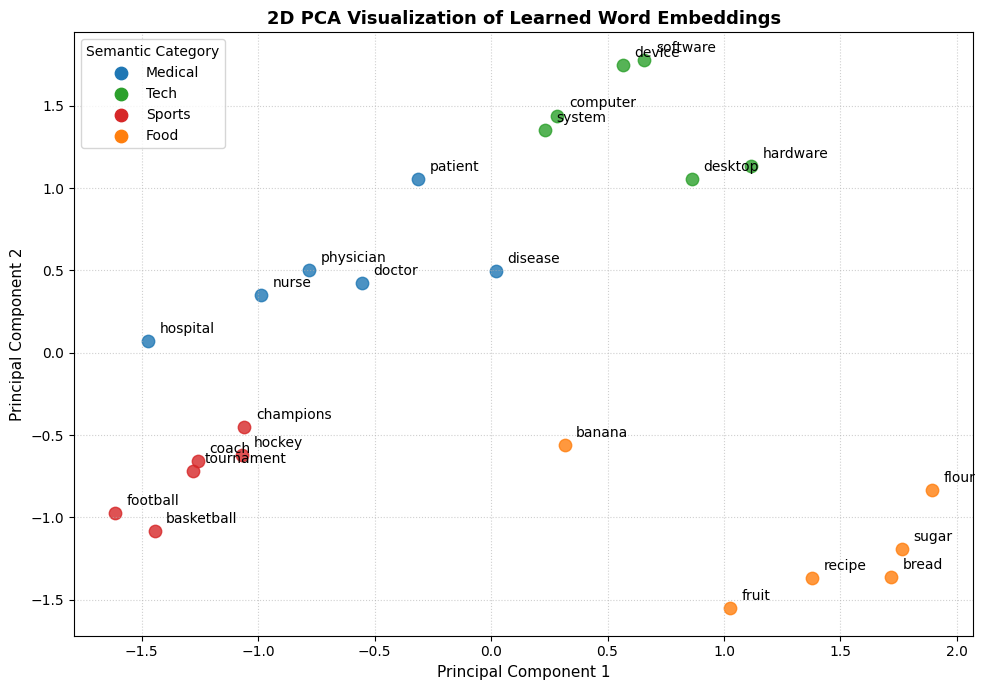

In [13]:
word_clusters = {
    "Medical": ["doctor", "physician", "hospital", "patient", "disease", "nurse"],
    "Tech": ["computer", "desktop", "hardware", "software", "system", "device"],
    "Sports": ["football", "basketball", "hockey", "tournament", "coach", "champions"],
    "Food": ["banana", "fruit", "flour", "recipe", "sugar", "bread"]
}

cluster_words = []
cluster_labels = []
for category, words in word_clusters.items():
    for w in words:
        if w in model_w2v.wv:
            cluster_words.append(w)
            cluster_labels.append(category)

cluster_vecs = np.array([model_w2v.wv[w] for w in cluster_words])

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(cluster_vecs)

plt.figure(figsize=(10, 7))
category_colors = {"Medical": "#1f77b4", "Tech": "#2ca02c", "Sports": "#d62728", "Food": "#ff7f0e"}

for i, word in enumerate(cluster_words):
    cat = cluster_labels[i]
    plt.scatter(coords[i, 0], coords[i, 1], color=category_colors[cat], s=80, alpha=0.8)
    plt.text(coords[i, 0] + 0.05, coords[i, 1] + 0.05, word, fontsize=10)

for cat, col in category_colors.items():
    plt.scatter([], [], color=col, label=cat, s=80)

plt.title("2D PCA Visualization of Learned Word Embeddings", fontsize=13, fontweight="bold")
plt.xlabel("Principal Component 1", fontsize=11)
plt.ylabel("Principal Component 2", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(title="Semantic Category")
plt.tight_layout()
plt.show()


## 13. Tổng kết & Xuất Bảng Kết quả Định lượng (results.csv)
Toàn bộ các chỉ số đo lường định lượng từ các thực nghiệm trên đã được tổng hợp và xuất ra file `results.csv` theo cấu trúc tiêu chuẩn của môn học.


In [14]:
df_results = pd.read_csv("results.csv")
print(f"Tong so ban ghi ket qua da ghi nhan: {len(df_results)}")
df_results.head(10)


Tong so ban ghi ket qua da ghi nhan: 60


,experiment_type,model_name,parameter,metric_name,metric_value,pair_or_query,target_or_candidate,score,rank
0,cooccurrence_matrix,Cooccurrence_Window_1,window=1,sparsity,0.9560,matrix_sparsity,non_zeros=64630,0.9560,1
1,cooccurrence_similarity,Cooccurrence_Window_1,window=1,cosine_similarity,0.3162,doctor-hospital,hospital,0.3162,1
2,cooccurrence_matrix,Cooccurrence_Window_2,window=2,sparsity,0.9221,matrix_sparsity,non_zeros=114401,0.9221,1
3,cooccurrence_similarity,Cooccurrence_Window_2,window=2,cosine_similarity,0.2372,doctor-hospital,hospital,0.2372,1
4,cooccurrence_matrix,Cooccurrence_Window_5,window=5,sparsity,0.8535,matrix_sparsity,non_zeros=215247,0.8535,1
5,cooccurrence_similarity,Cooccurrence_Window_5,window=5,cosine_similarity,0.4535,doctor-hospital,hospital,0.4535,1
6,context_window_effect,Word2Vec_SkipGram_D100,"window=2,5,10",cosine_similarity,0.7848,doctor-physician,"w2=0.8252, w5=0.7848, w10=0.8469",0.7848,1
7,context_window_effect,Word2Vec_SkipGram_D100,"window=2,5,10",cosine_similarity,0.5701,doctor-hospital,"w2=0.6111, w5=0.5701, w10=0.6325",0.5701,1
8,context_window_effect,Word2Vec_SkipGram_D100,"window=2,5,10",cosine_similarity,0.7398,cat-dog,"w2=0.7621, w5=0.7398, w10=0.6734",0.7398,1
9,context_window_effect,Word2Vec_SkipGram_D100,"window=2,5,10",cosine_similarity,0.5317,doctor-disease,"w2=0.4978, w5=0.5317, w10=0.5939",0.5317,1
